IDEAS<br>
meter todas las boludeces de distancia dia y demás en un dataframe de pandas que estoy como pelotudo poniendolas en listas separadas<br>
besos

In [13]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp


#IGUAL PARA TODOS LOS EXPERIMENTOS AL MENOS DEL MIERCOLES PASADO QSY NO CREO QUE NADIE VAYA A LEER ESTO HOLA CUCHU

f_0=16.43e3

distancias=[50,70,89,110,130,160,170,190,200]
indicesd1= list(range(7,11))+list(range(14,19))


In [14]:
dia_1=pd.DataFrame(columns=['Distancias','Voltajes_RMS_Osciloscopio','Voltajes_Lock_In_Virtual','Voltajes_fit',''])
dia_1_fitparams=pd.DataFrame(columns=['A','B','C','D','Error A','Error B','Error C','Error D'])

In [15]:
dick=dict()

for i in range (7,19):
    if i<10:
        dick[f'dato_{i}']= pd.read_csv(f'datosdia1/SDS0000{i}.CSV',header=1)[:-50] #CORTO EN -50 PORQUE TENIA UN ERROR QUE NO SE DE DONDE PORONGA SALIÓ
                                                                                   #bue por qué gritaba
        # print(f'SDS0000{i}')
    else:
        dick[f'dato_{i}'] = pd.read_csv(f'datosdia1/SDS000{i}.CSV',header=1)[:-50]
        # print(f'SDS000{i}')

In [16]:
%%script == False
for i in range(7,19):
    
    plt.figure(figsize=(16,9))
    plt.plot(dick[f'dato_{i}']['Second'],dick[f'dato_{i}']['Volt'])
    plt.plot(dick[f'dato_{i}']['Second'],dick[f'dato_{i}']['Volt.1'])

Couldn't find program: '=='


In [17]:
def funkfit (x,a,b,c,d):
    """ a*np.sin(2 pi* b * x + c )+d """
    return a*np.sin(2*np.pi*b*x+c)+d

In [18]:
def lock_in(datos,f):
    x,y =datos['Second'],datos['Volt.1']
    
    # print(x,'\n',y)
    dx=x.iloc[-1]-x.iloc[0]
    
    y_cos= np.cos(2*np.pi*f*x)* y
    y_sin= np.sin(2*np.pi*f*x)* y

    U_cos=1/dx*np.trapz(y_cos,x=x)
    U_sin=1/dx*np.trapz(y_sin,x=x)

    
    # plt.figure()
    # plt.plot(y_cos)
    r=((2*U_cos)**2+(2*U_sin)**2)**.5
    phi=np.arctan2(U_sin,U_cos)

    return r,phi

In [46]:
def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

C:\Users\soysa\AppData\Local\Temp\ipykernel_12448\1486227282.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dia_1_fitparams = pd.concat([dia_1_fitparams, df_input])


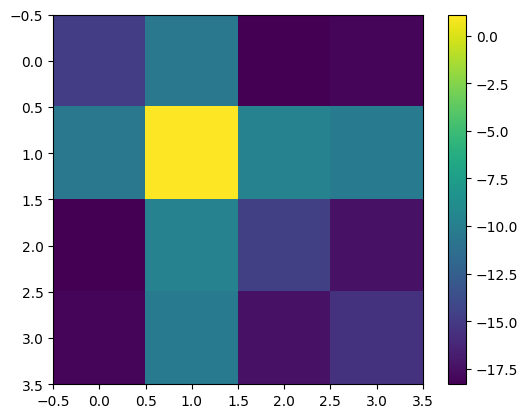

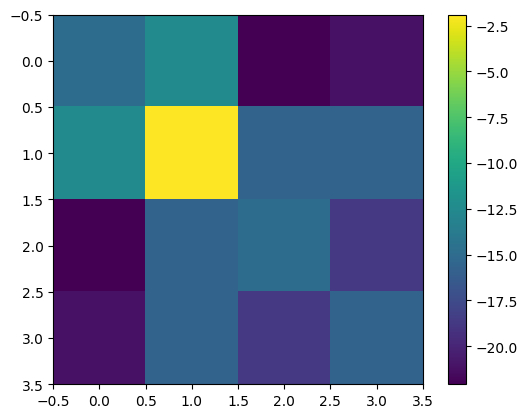

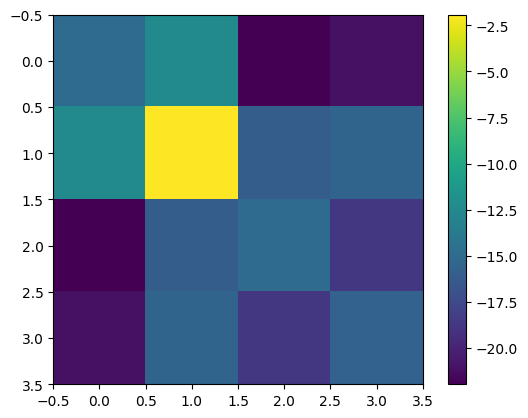

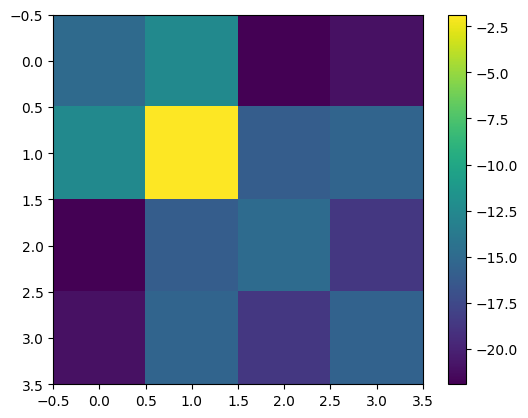

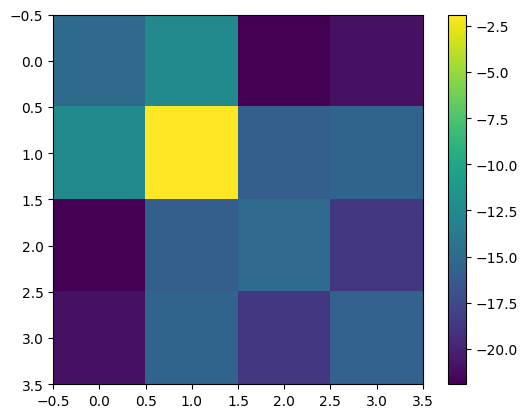

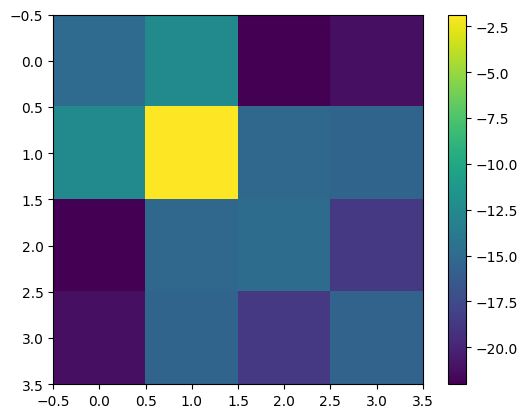

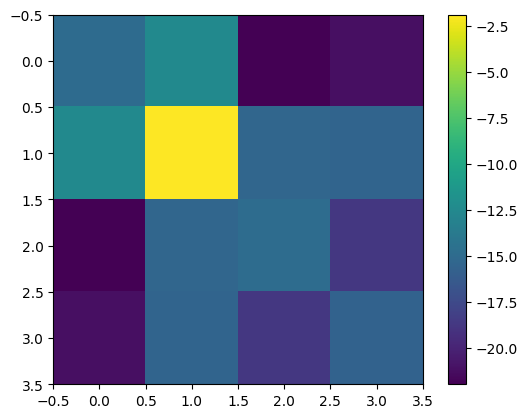

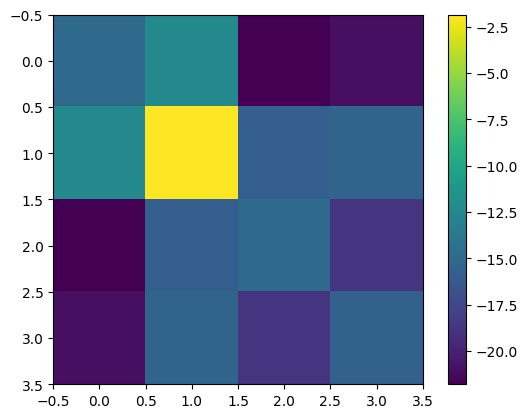

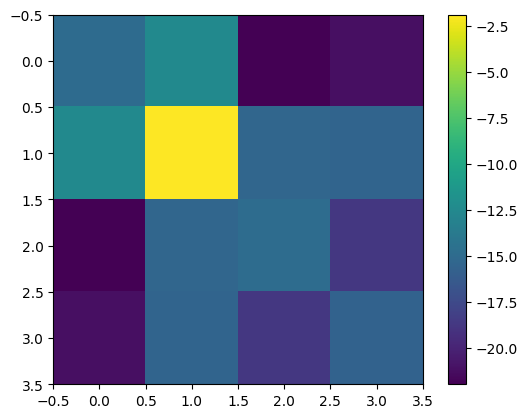

In [19]:
for i in indicesd1:
    x,y =dick[f'dato_{i}']['Second'],dick[f'dato_{i}']['Volt']
    
    p0=[0.660 , f_0 , 0 , 0] #el valor inicial es 0.660 porque fue el que medimos con el osciloscopio, a este no le mandé nada raro de lockin
    
    popt,pcov=scp.optimize.curve_fit(funkfit,xdata=x,ydata=y,p0=p0)
    
    pcovdiag=np.diag(pcov)
    
    data_row=np.array([np.concatenate([popt,pcovdiag])])
    
    df_input=pd.DataFrame(columns=dia_1_fitparams.columns,data=data_row)
    
    dia_1_fitparams = pd.concat([dia_1_fitparams, df_input])
    
    plt.figure()
    plt.imshow(np.log(np.abs(pcov)))
    plt.colorbar()

In [20]:
dia_1_fitparams

,A,B,C,D,Error A,Error B,Error C,Error D
0,0.921737,16421.650660,0.550107,0.014811,3.766938e-07,3.011254,4.310715e-07,1.868541e-07
0,0.967679,16437.930779,0.010198,0.010743,3.132963e-07,0.149545,3.316509e-07,1.560167e-07
0,0.967078,16436.227209,0.002765,0.009294,3.086387e-07,0.147458,3.270809e-07,1.536853e-07
0,0.966763,16433.417200,0.002528,0.009075,3.210190e-07,0.153381,3.403164e-07,1.598257e-07
0,0.966833,16431.588206,0.005129,0.010766,3.181144e-07,0.151908,3.371217e-07,1.583632e-07
0,0.966878,16427.392317,0.018778,0.008986,3.249805e-07,0.155016,3.441858e-07,1.617403e-07
0,0.967658,16428.374951,0.015075,0.009516,3.216334e-07,0.153208,3.401286e-07,1.600840e-07
0,0.968229,16423.567498,0.003156,0.006704,3.270338e-07,0.155453,3.452751e-07,1.627347e-07
0,0.967098,16426.835134,0.013979,0.012696,3.120628e-07,0.148774,3.303385e-07,1.553082e-07


In [21]:
V=[]
for i,j in enumerate(indicesd1):
    V+=[lock_in(dick[f'dato_{j}'],dia_1_fitparams.iloc[i,1])[0]]
    #plt.plot(dick[f'dato_{j}']['Second'],funkfit(dick[f'dato_{j}']['Second'],dia_1_fitparams['A'].iloc[i],dia_1_fitparams['B'].iloc[i],dia_1_fitparams['C'].iloc[i],dia_1_fitparams['D'].iloc[i]))

V=sorted(V,reverse=True)

Text(0, 0.5, 'Voltaje [V]')

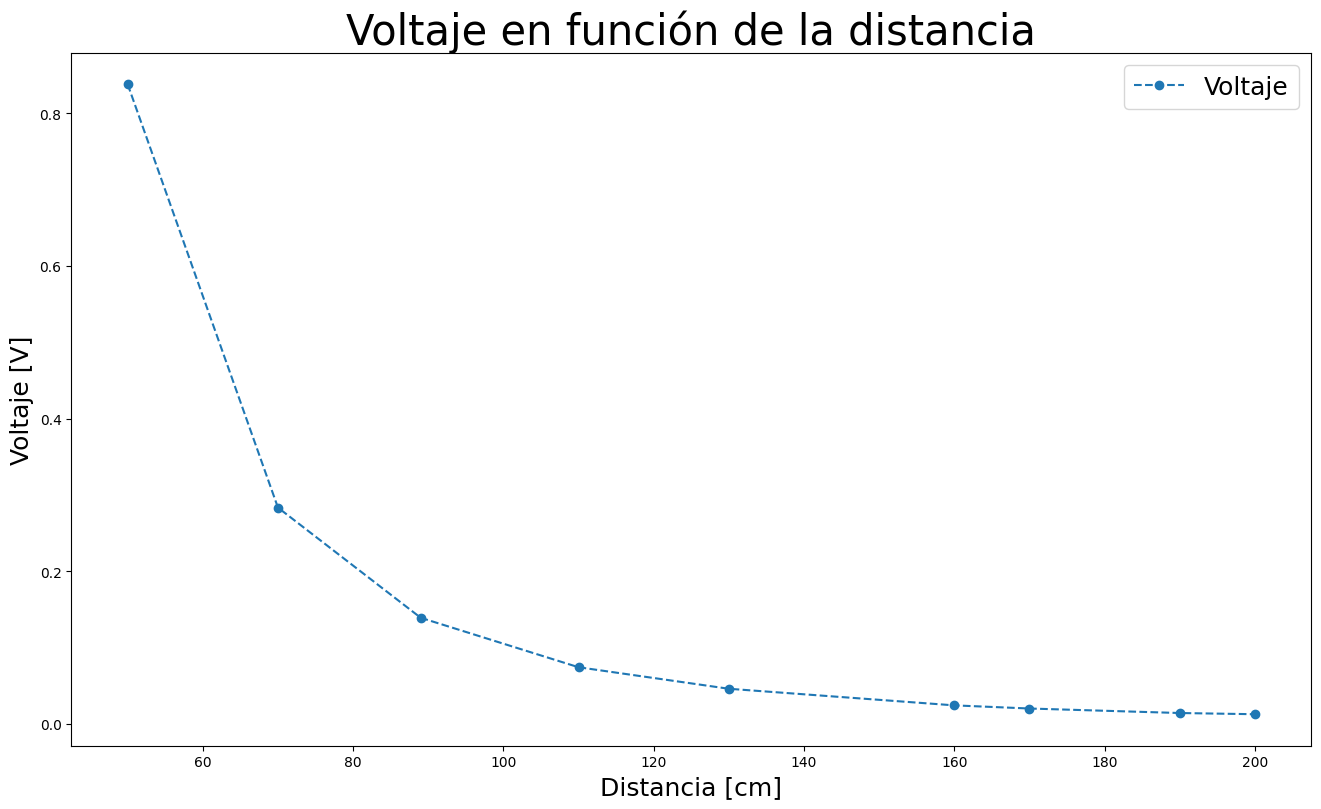

In [32]:
plt.figure(figsize=(16,9))
plt.plot(distancias,V,'o--')

plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [51]:
P=np.polyfit(np.log(distancias),np.log(V),1)
#P=np.polyfit(np.log(distancias[1:-1]),np.log(V[1:-1]),1)
P


array([-3.0033376 , 11.53189519])

Text(0, 0.5, 'Voltaje [V]')

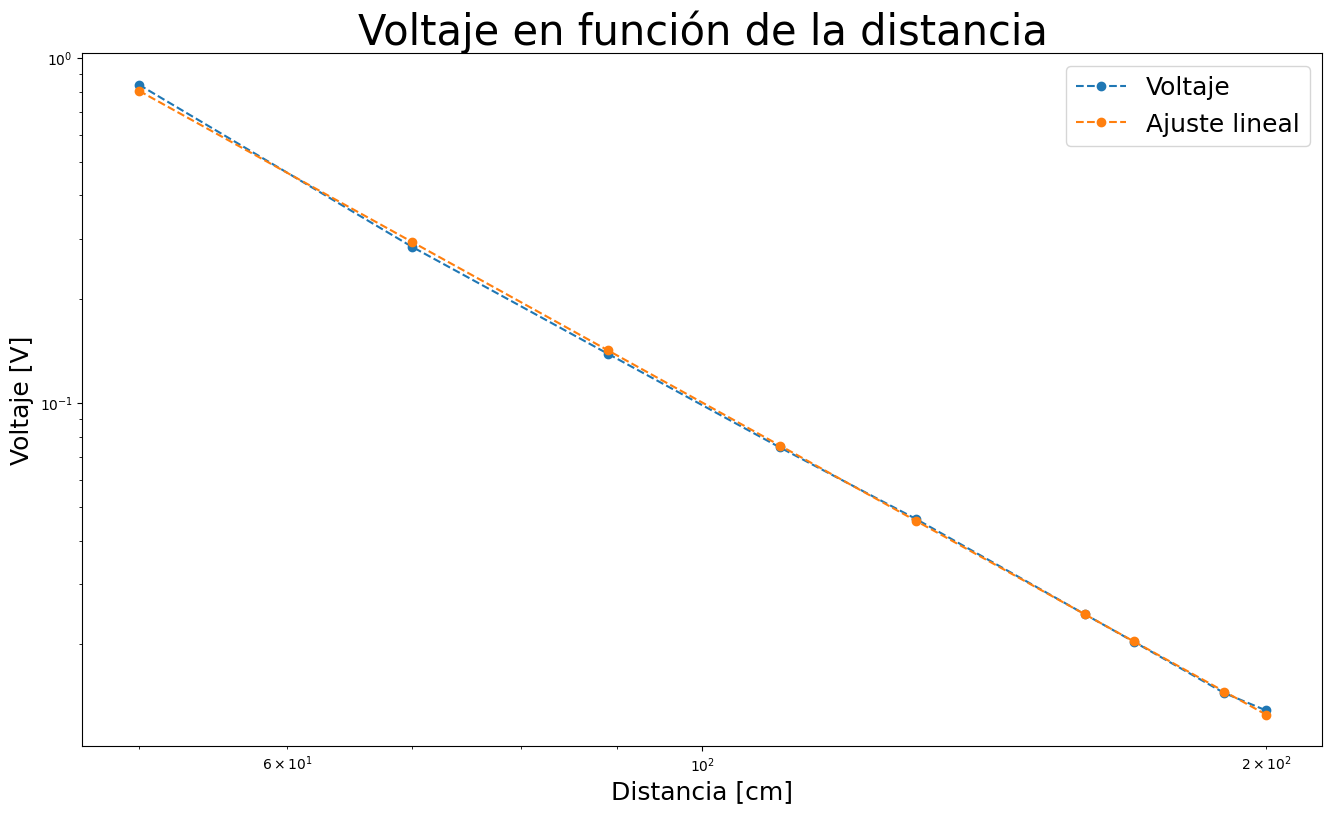

In [52]:
plt.figure(figsize=(16,9))
plt.loglog(distancias,V,'o--')
plt.loglog(distancias,B_short(distancias,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [58]:
pd.DataFrame({'d':distancias,'V':V}).to_csv('V_1.csv',index=False)